# 10. Hybrid Pipeline Experiments (Stage 1 + Stage 2)
In visual search, combining models yields superior results. Single models like standard YOLO miss detailed categories, and CLIP/FashionCLIP cannot localize on its own.
We combine:
- **Stage 1 (Detector)**: Grounding DINO (or YOLO) to detect candidate regions (regions containing any clothing/accessory item).
- **Stage 2 (Classifier)**: FashionCLIP to crop and classify each candidate region into fine-grained fashion classes.

In this notebook, we:
1. Initialize the `HybridPipeline` using dependency injection.
2. Run Stage 1 (Grounding DINO) to locate objects.
3. Run Stage 2 (FashionCLIP) to refine their labels.
4. Compare before (Stage 1) and after (Stage 2) classifications.



In [16]:
import os
import sys

sys.path.append(os.path.abspath("."))

from fashion_detector.config import Config
from fashion_detector.models.grounding_dino import GroundingDinoDetector
from fashion_detector.models.vision_llm import VisionLlmDetector
from fashion_detector.models.fashion_clip import FashionClipDetector
from fashion_detector.pipeline import HybridPipeline
from fashion_detector.utils import load_image, generate_interactive_html, visualize_detections, display_img
from IPython.display import HTML

config = Config("config/config.yaml")

# Instantiate components
# detector = GroundingDinoDetector(config)
detector = VisionLlmDetector(config)
classifier = FashionClipDetector(config)

# Instantiate the pipeline (Dependency Injection)
pipeline = HybridPipeline(detector=detector, classifier=classifier)

[2026-07-21 15:42:16] [INFO] [fashion_detector:config.py:159] - Configuration loaded from config/config.yaml. Device set to: mps


## Execute the Hybrid Pipeline


In [17]:
user_categories = [
        'dresses', 'tops', 'sweaters', 'shirts', 'jackets blazers', 'coats', 'pants', 'jeans', 'skirts', 
        'suits sets', 'jumpsuits', 'sneakers', 'flats', 'loafers', 'mules slides', 'heels', 'sandals', 
        'boots', 'tote bags', 'shoulder bags', 'crossbody bags', 'handle bags', 'backpacks', 'belt bags', 
        'clutches', 'sunglasses', 'scarves shawls', 'belts', 'wallets', 'hats', 'watches', 'jewelry', 
        'earrings', 'necklaces', 'bracelets', 'rings', 'brooches', 't shirts', 'shirts', 'sweaters', 
        'jackets', 'blazers', 'coats', 'pants', 'jeans', 'suits', 'shorts', 'dress shoes', 'loafers', 
        'sneakers', 'boots', 'sandals', 'briefcases', 'backpacks', 'duffel bags', 'messenger bags', 
        'tote bags', 'sunglasses', 'belts', 'ties', 'scarves', 'wallets', 'hats', 'watches'
    ]

def execute_pipeline(image_path, categories=user_categories):
    image = load_image(image_path)
    detections = pipeline.detect(image, categories=categories)
    print(f"Hybrid pipeline detected {len(detections)} fashion items:")
    for d in detections:
        print(
            f"- {d.label.capitalize()} (refined from {d.metadata.get('proposal_label')}): score={d.score:.2f}"
        )
    visualize_detections(image, detector._to_dict(detections))
    return detections

[2026-07-21 15:42:22] [INFO] [fashion_detector:utils.py:32] - Loading image from local path: data/fashion_model_street.jpg
[2026-07-21 15:42:22] [INFO] [fashion_detector:logging.py:98] - Starting: Hybrid Pipeline Total Execution
[2026-07-21 15:42:22] [INFO] [fashion_detector:pipeline.py:167] - Executing Stage 1: Region Proposal...
[2026-07-21 15:42:22] [INFO] [fashion_detector:logging.py:98] - Starting: Vision LLM Inference
[2026-07-21 15:42:22] [INFO] [fashion_detector:vision_llm.py:109] - Querying Vision LLM openai/google/gemma-4-e2b via LiteLLM...
[2026-07-21 15:42:30] [INFO] [fashion_detector:vision_llm.py:175] - Vision LLM detected 4 items.
[2026-07-21 15:42:30] [INFO] [fashion_detector:logging.py:103] - Completed: Vision LLM Inference in 7.5534 seconds
[2026-07-21 15:42:30] [INFO] [fashion_detector:pipeline.py:244] - Stage 1 yielded 4 proposals, filtered down to 4 unique boxes.
[2026-07-21 15:42:30] [INFO] [fashion_detector:pipeline.py:252] - Executing Stage 2: FashionCLIP Crop C


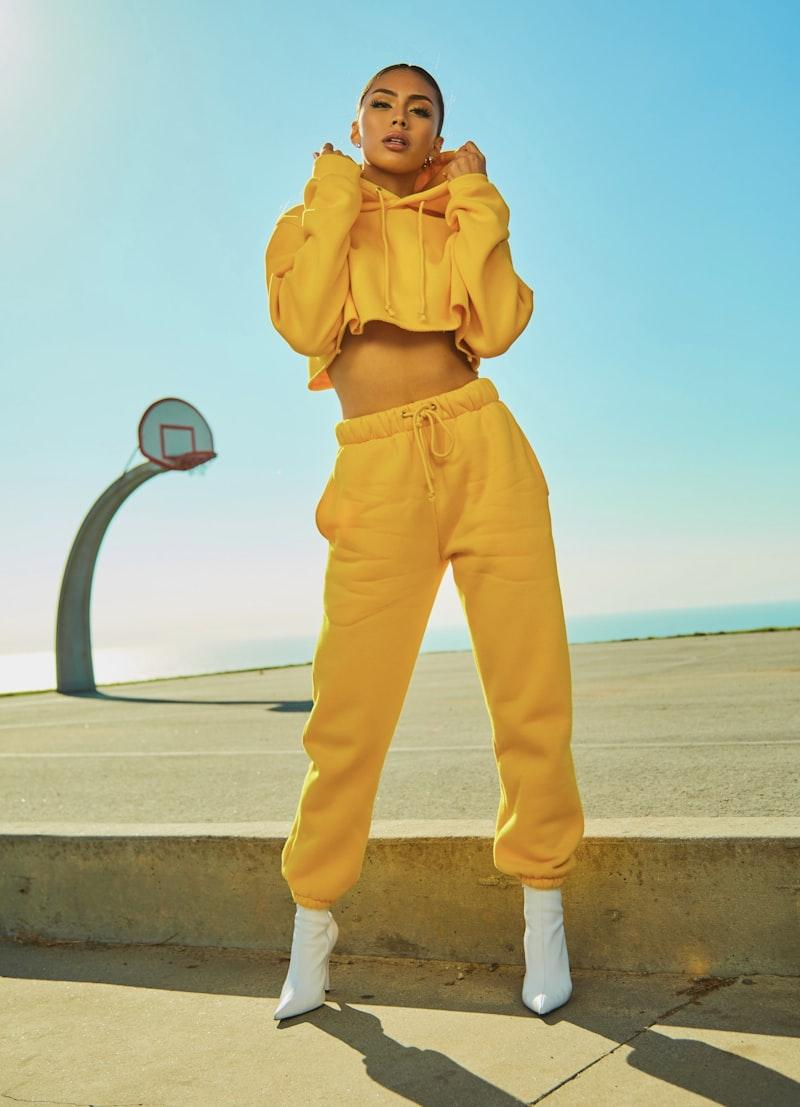

In [18]:
image_path = "data/fashion_model_street.jpg"
detections = execute_pipeline(image_path)

In [4]:
# detections = execute_pipeline('/Users/sunnyraj/Downloads/images.jpeg')

In [5]:
# detections = execute_pipeline('/Users/sunnyraj/Downloads/images-2.jpeg')

[2026-07-21 15:43:10] [INFO] [fashion_detector:utils.py:32] - Loading image from local path: /Users/sunnyraj/Downloads/images-3.jpeg
[2026-07-21 15:43:10] [INFO] [fashion_detector:logging.py:98] - Starting: Hybrid Pipeline Total Execution
[2026-07-21 15:43:10] [INFO] [fashion_detector:pipeline.py:167] - Executing Stage 1: Region Proposal...
[2026-07-21 15:43:10] [INFO] [fashion_detector:logging.py:98] - Starting: Vision LLM Inference
[2026-07-21 15:43:10] [INFO] [fashion_detector:vision_llm.py:109] - Querying Vision LLM openai/google/gemma-4-e2b via LiteLLM...
[2026-07-21 15:43:36] [INFO] [fashion_detector:vision_llm.py:175] - Vision LLM detected 6 items.
[2026-07-21 15:43:36] [INFO] [fashion_detector:logging.py:103] - Completed: Vision LLM Inference in 25.6613 seconds
[2026-07-21 15:43:36] [INFO] [fashion_detector:pipeline.py:244] - Stage 1 yielded 6 proposals, filtered down to 6 unique boxes.
[2026-07-21 15:43:36] [INFO] [fashion_detector:pipeline.py:252] - Executing Stage 2: Fashion


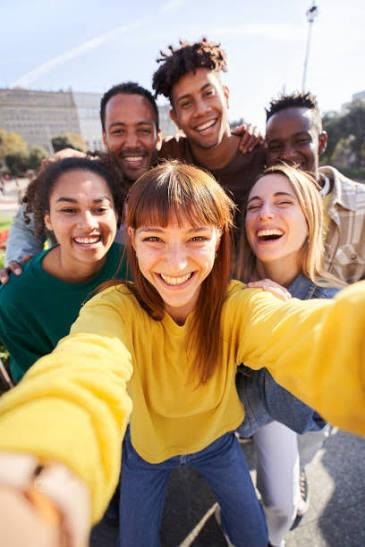

[2026-07-21 15:43:36] [INFO] [fashion_detector:utils.py:32] - Loading image from local path: /Users/sunnyraj/Downloads/images-10.jpeg
[2026-07-21 15:43:36] [INFO] [fashion_detector:logging.py:98] - Starting: Hybrid Pipeline Total Execution
[2026-07-21 15:43:36] [INFO] [fashion_detector:pipeline.py:167] - Executing Stage 1: Region Proposal...
[2026-07-21 15:43:36] [INFO] [fashion_detector:logging.py:98] - Starting: Vision LLM Inference
[2026-07-21 15:43:36] [INFO] [fashion_detector:vision_llm.py:109] - Querying Vision LLM openai/google/gemma-4-e2b via LiteLLM...
[2026-07-21 15:43:39] [INFO] [fashion_detector:vision_llm.py:175] - Vision LLM detected 1 items.
[2026-07-21 15:43:39] [INFO] [fashion_detector:logging.py:103] - Completed: Vision LLM Inference in 3.3982 seconds
[2026-07-21 15:43:39] [INFO] [fashion_detector:pipeline.py:244] - Stage 1 yielded 1 proposals, filtered down to 1 unique boxes.
[2026-07-21 15:43:39] [INFO] [fashion_detector:pipeline.py:252] - Executing Stage 2: Fashion


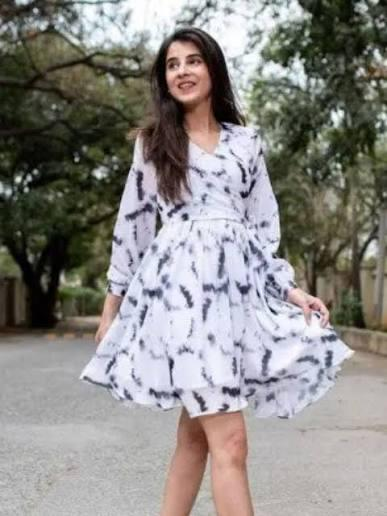

[2026-07-21 15:43:39] [INFO] [fashion_detector:utils.py:32] - Loading image from local path: /Users/sunnyraj/Downloads/images-11.jpeg
[2026-07-21 15:43:39] [INFO] [fashion_detector:logging.py:98] - Starting: Hybrid Pipeline Total Execution
[2026-07-21 15:43:39] [INFO] [fashion_detector:pipeline.py:167] - Executing Stage 1: Region Proposal...
[2026-07-21 15:43:39] [INFO] [fashion_detector:logging.py:98] - Starting: Vision LLM Inference
[2026-07-21 15:43:39] [INFO] [fashion_detector:vision_llm.py:109] - Querying Vision LLM openai/google/gemma-4-e2b via LiteLLM...
[2026-07-21 15:43:43] [INFO] [fashion_detector:vision_llm.py:175] - Vision LLM detected 1 items.
[2026-07-21 15:43:43] [INFO] [fashion_detector:logging.py:103] - Completed: Vision LLM Inference in 3.4923 seconds
[2026-07-21 15:43:43] [INFO] [fashion_detector:pipeline.py:244] - Stage 1 yielded 1 proposals, filtered down to 1 unique boxes.
[2026-07-21 15:43:43] [INFO] [fashion_detector:pipeline.py:252] - Executing Stage 2: Fashion


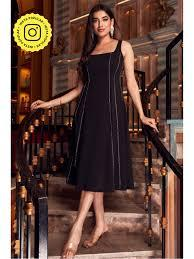

[2026-07-21 15:43:43] [INFO] [fashion_detector:utils.py:32] - Loading image from local path: /Users/sunnyraj/Downloads/images.jpeg
[2026-07-21 15:43:43] [INFO] [fashion_detector:logging.py:98] - Starting: Hybrid Pipeline Total Execution
[2026-07-21 15:43:43] [INFO] [fashion_detector:pipeline.py:167] - Executing Stage 1: Region Proposal...
[2026-07-21 15:43:43] [INFO] [fashion_detector:logging.py:98] - Starting: Vision LLM Inference
[2026-07-21 15:43:43] [INFO] [fashion_detector:vision_llm.py:109] - Querying Vision LLM openai/google/gemma-4-e2b via LiteLLM...
[2026-07-21 15:44:05] [INFO] [fashion_detector:vision_llm.py:175] - Vision LLM detected 5 items.
[2026-07-21 15:44:05] [INFO] [fashion_detector:logging.py:103] - Completed: Vision LLM Inference in 21.8902 seconds
[2026-07-21 15:44:05] [INFO] [fashion_detector:pipeline.py:244] - Stage 1 yielded 5 proposals, filtered down to 5 unique boxes.
[2026-07-21 15:44:05] [INFO] [fashion_detector:pipeline.py:252] - Executing Stage 2: FashionCL


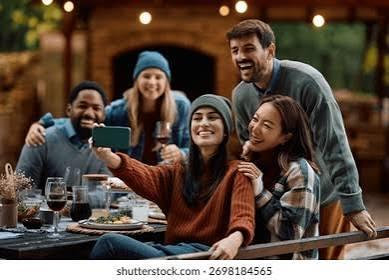

[2026-07-21 15:44:05] [INFO] [fashion_detector:utils.py:32] - Loading image from local path: /Users/sunnyraj/Downloads/images-2.jpeg
[2026-07-21 15:44:05] [INFO] [fashion_detector:logging.py:98] - Starting: Hybrid Pipeline Total Execution
[2026-07-21 15:44:05] [INFO] [fashion_detector:pipeline.py:167] - Executing Stage 1: Region Proposal...
[2026-07-21 15:44:05] [INFO] [fashion_detector:logging.py:98] - Starting: Vision LLM Inference
[2026-07-21 15:44:05] [INFO] [fashion_detector:vision_llm.py:109] - Querying Vision LLM openai/google/gemma-4-e2b via LiteLLM...
[2026-07-21 15:44:21] [INFO] [fashion_detector:vision_llm.py:175] - Vision LLM detected 5 items.
[2026-07-21 15:44:21] [INFO] [fashion_detector:logging.py:103] - Completed: Vision LLM Inference in 16.0223 seconds
[2026-07-21 15:44:21] [INFO] [fashion_detector:pipeline.py:244] - Stage 1 yielded 5 proposals, filtered down to 5 unique boxes.
[2026-07-21 15:44:21] [INFO] [fashion_detector:pipeline.py:252] - Executing Stage 2: Fashion


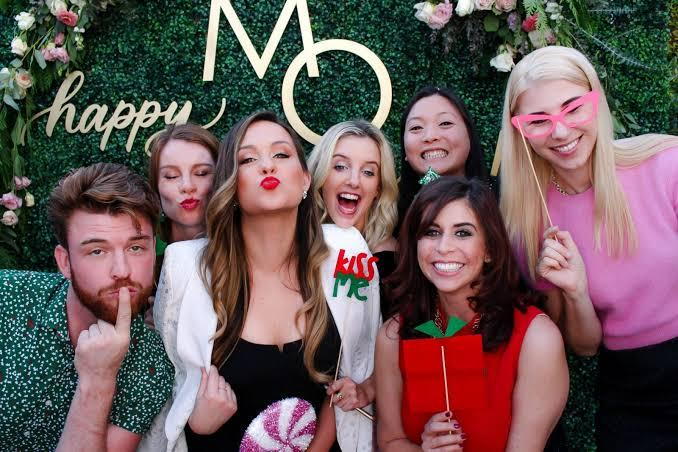

[2026-07-21 15:44:21] [INFO] [fashion_detector:utils.py:32] - Loading image from local path: /Users/sunnyraj/Downloads/images-5.jpeg
[2026-07-21 15:44:21] [INFO] [fashion_detector:logging.py:98] - Starting: Hybrid Pipeline Total Execution
[2026-07-21 15:44:21] [INFO] [fashion_detector:pipeline.py:167] - Executing Stage 1: Region Proposal...
[2026-07-21 15:44:21] [INFO] [fashion_detector:logging.py:98] - Starting: Vision LLM Inference
[2026-07-21 15:44:21] [INFO] [fashion_detector:vision_llm.py:109] - Querying Vision LLM openai/google/gemma-4-e2b via LiteLLM...
[2026-07-21 15:44:29] [INFO] [fashion_detector:vision_llm.py:175] - Vision LLM detected 1 items.
[2026-07-21 15:44:29] [INFO] [fashion_detector:logging.py:103] - Completed: Vision LLM Inference in 7.8135 seconds
[2026-07-21 15:44:29] [INFO] [fashion_detector:pipeline.py:244] - Stage 1 yielded 1 proposals, filtered down to 1 unique boxes.
[2026-07-21 15:44:29] [INFO] [fashion_detector:pipeline.py:252] - Executing Stage 2: FashionC


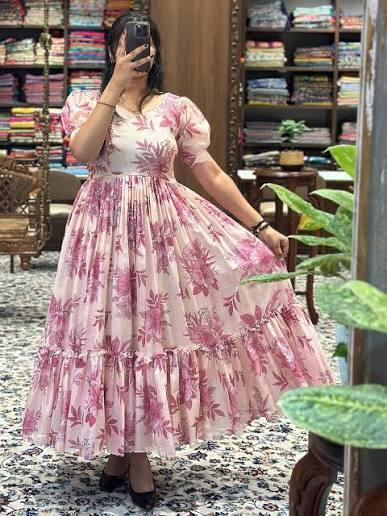

[2026-07-21 15:44:29] [INFO] [fashion_detector:utils.py:32] - Loading image from local path: /Users/sunnyraj/Downloads/images-16.jpeg
[2026-07-21 15:44:29] [INFO] [fashion_detector:logging.py:98] - Starting: Hybrid Pipeline Total Execution
[2026-07-21 15:44:29] [INFO] [fashion_detector:pipeline.py:167] - Executing Stage 1: Region Proposal...
[2026-07-21 15:44:29] [INFO] [fashion_detector:logging.py:98] - Starting: Vision LLM Inference
[2026-07-21 15:44:29] [INFO] [fashion_detector:vision_llm.py:109] - Querying Vision LLM openai/google/gemma-4-e2b via LiteLLM...
[2026-07-21 15:44:45] [INFO] [fashion_detector:vision_llm.py:175] - Vision LLM detected 3 items.
[2026-07-21 15:44:45] [INFO] [fashion_detector:logging.py:103] - Completed: Vision LLM Inference in 15.7370 seconds
[2026-07-21 15:44:45] [INFO] [fashion_detector:pipeline.py:244] - Stage 1 yielded 3 proposals, filtered down to 2 unique boxes.
[2026-07-21 15:44:45] [INFO] [fashion_detector:pipeline.py:252] - Executing Stage 2: Fashio


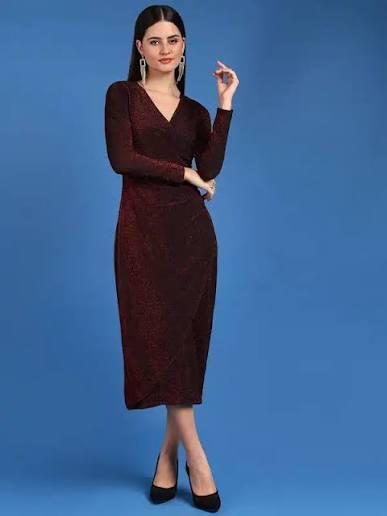

[2026-07-21 15:44:45] [INFO] [fashion_detector:utils.py:32] - Loading image from local path: /Users/sunnyraj/Downloads/images-9.jpeg
[2026-07-21 15:44:45] [INFO] [fashion_detector:logging.py:98] - Starting: Hybrid Pipeline Total Execution
[2026-07-21 15:44:45] [INFO] [fashion_detector:pipeline.py:167] - Executing Stage 1: Region Proposal...
[2026-07-21 15:44:45] [INFO] [fashion_detector:logging.py:98] - Starting: Vision LLM Inference
[2026-07-21 15:44:45] [INFO] [fashion_detector:vision_llm.py:109] - Querying Vision LLM openai/google/gemma-4-e2b via LiteLLM...
[2026-07-21 15:44:49] [INFO] [fashion_detector:vision_llm.py:175] - Vision LLM detected 2 items.
[2026-07-21 15:44:49] [INFO] [fashion_detector:logging.py:103] - Completed: Vision LLM Inference in 4.4329 seconds
[2026-07-21 15:44:49] [INFO] [fashion_detector:pipeline.py:244] - Stage 1 yielded 2 proposals, filtered down to 2 unique boxes.
[2026-07-21 15:44:49] [INFO] [fashion_detector:pipeline.py:252] - Executing Stage 2: FashionC


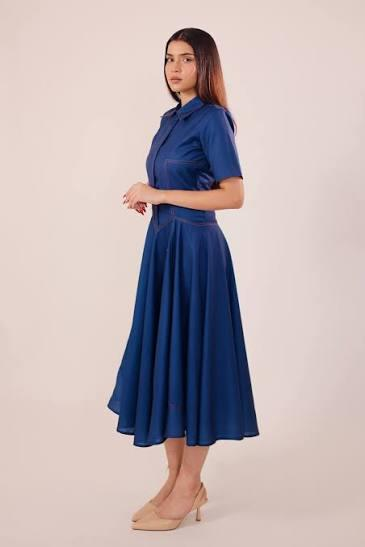

[2026-07-21 15:44:49] [INFO] [fashion_detector:utils.py:32] - Loading image from local path: /Users/sunnyraj/Downloads/images-8.jpeg
[2026-07-21 15:44:49] [INFO] [fashion_detector:logging.py:98] - Starting: Hybrid Pipeline Total Execution
[2026-07-21 15:44:49] [INFO] [fashion_detector:pipeline.py:167] - Executing Stage 1: Region Proposal...
[2026-07-21 15:44:49] [INFO] [fashion_detector:logging.py:98] - Starting: Vision LLM Inference
[2026-07-21 15:44:49] [INFO] [fashion_detector:vision_llm.py:109] - Querying Vision LLM openai/google/gemma-4-e2b via LiteLLM...
[2026-07-21 15:44:55] [INFO] [fashion_detector:vision_llm.py:175] - Vision LLM detected 3 items.
[2026-07-21 15:44:55] [INFO] [fashion_detector:logging.py:103] - Completed: Vision LLM Inference in 5.4503 seconds
[2026-07-21 15:44:55] [INFO] [fashion_detector:pipeline.py:244] - Stage 1 yielded 3 proposals, filtered down to 3 unique boxes.
[2026-07-21 15:44:55] [INFO] [fashion_detector:pipeline.py:252] - Executing Stage 2: FashionC


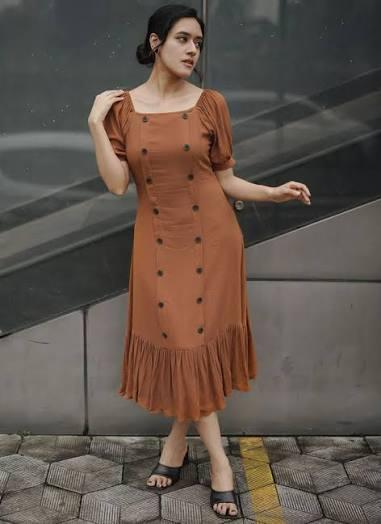

[2026-07-21 15:44:55] [INFO] [fashion_detector:utils.py:32] - Loading image from local path: /Users/sunnyraj/Downloads/images-17.jpeg
[2026-07-21 15:44:55] [INFO] [fashion_detector:logging.py:98] - Starting: Hybrid Pipeline Total Execution
[2026-07-21 15:44:55] [INFO] [fashion_detector:pipeline.py:167] - Executing Stage 1: Region Proposal...
[2026-07-21 15:44:55] [INFO] [fashion_detector:logging.py:98] - Starting: Vision LLM Inference
[2026-07-21 15:44:55] [INFO] [fashion_detector:vision_llm.py:109] - Querying Vision LLM openai/google/gemma-4-e2b via LiteLLM...


In [ ]:
for image in os.listdir('/Users/sunnyraj/Downloads/'):
    if image.endswith('.jpeg') or image.endswith('.jpg') or image.endswith('.png'):
        image_path = os.path.join('/Users/sunnyraj/Downloads/', image)
        detections = execute_pipeline(image_path)

[2026-07-21 15:08:29] [INFO] [fashion_detector:utils.py:32] - Loading image from local path: /Users/sunnyraj/Downloads/images-4.jpeg
[2026-07-21 15:08:29] [INFO] [fashion_detector:logging.py:98] - Starting: Hybrid Pipeline Total Execution
[2026-07-21 15:08:29] [INFO] [fashion_detector:pipeline.py:167] - Executing Stage 1: Region Proposal...
[2026-07-21 15:08:29] [INFO] [fashion_detector:pipeline.py:187] - Hierarchical Mode: Map target categories to 13 parent queries.
[2026-07-21 15:08:29] [INFO] [fashion_detector:pipeline.py:193] - Running Grounding DINO Batch 1/4: ['wallet', 'headwear', 'eyewear', 'bag']
[2026-07-21 15:08:29] [INFO] [fashion_detector:logging.py:98] - Starting: Grounding DINO Inference
[2026-07-21 15:08:30] [INFO] [fashion_detector:grounding_dino.py:138] - Grounding DINO detected 4 items.
[2026-07-21 15:08:30] [INFO] [fashion_detector:logging.py:103] - Completed: Grounding DINO Inference in 1.2128 seconds
[2026-07-21 15:08:30] [INFO] [fashion_detector:pipeline.py:193] 


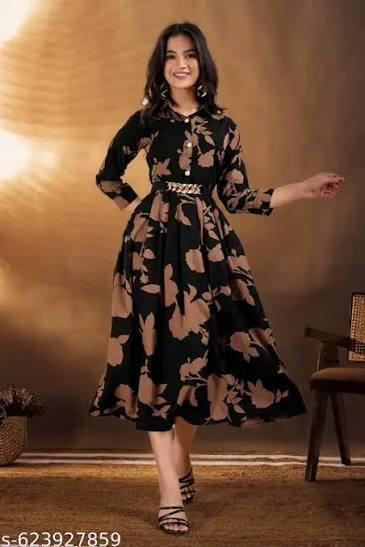

In [7]:
detections = execute_pipeline('/Users/sunnyraj/Downloads/images-4.jpeg')